In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np


In [12]:
def draw_bar(ax, file_path, key,q=0.8,title=None):

    with open(file_path, 'r') as f:
        data = json.load(f)

    bins = np.array(data['bins'], dtype=float)      # N+1
    chosen = np.array(data[key], dtype=int)    # N

    idx = (bins[1:] + bins[:-1]) / 2
    widths = bins[1:] - bins[:-1]

    # ===== 80% rank =====
    total = chosen.sum()
    r = int(np.ceil(q * total))

    cum = np.cumsum(chosen)
    q_idx = int(np.searchsorted(cum, r, side="left"))

    cum_before = cum[q_idx - 1] if q_idx > 0 else 0
    offset = r - cum_before
    frac = (offset - 0.5) / chosen[q_idx]
    frac = np.clip(frac, 0.0, 1.0)

    q_entropy = bins[q_idx] + frac * (bins[q_idx + 1] - bins[q_idx])

    # ===== plot =====
    ax.set_yscale('log')
    ax.bar(idx, chosen, width=widths, edgecolor='black')
    ax.axvline(q_entropy, color='red', linestyle='--', linewidth=2,label=f"The {int(q*100)}th percentile = {q_entropy:.3f}")
    ax.legend(fontsize=9)
    ax.set_xlim(bins[0], bins[-1])
    if title is None:
        ax.set_title(f"Epoch {file_path.split('_')[-1].split('.')[0]}")
    else:
        ax.set_title(f"Epoch {title}")

def draw_graph(pretrained,sft,exp_dir,key):


    fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    draw_bar(axes[0],f"{pretrained}/entropy_hist_epoch_1.json",key,q=0.8,title=-1)
    draw_bar(axes[1],f"{sft}/entropy_hist_epoch_1.json",key,q=0.8,title=0)

    for epoch in range(1, 7):
        file_path = f"{exp_dir}/entropy_hist_epoch_{epoch}.json"
        draw_bar(axes[epoch+1], file_path,key, q=0.8)

    # ===== 全局标签 =====
    fig.supxlabel("Entropy", fontsize=12)
    fig.supylabel("Count (log scale)", fontsize=12)
    fig.suptitle(f"Entropy Histogram across Epochs-{key}", fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


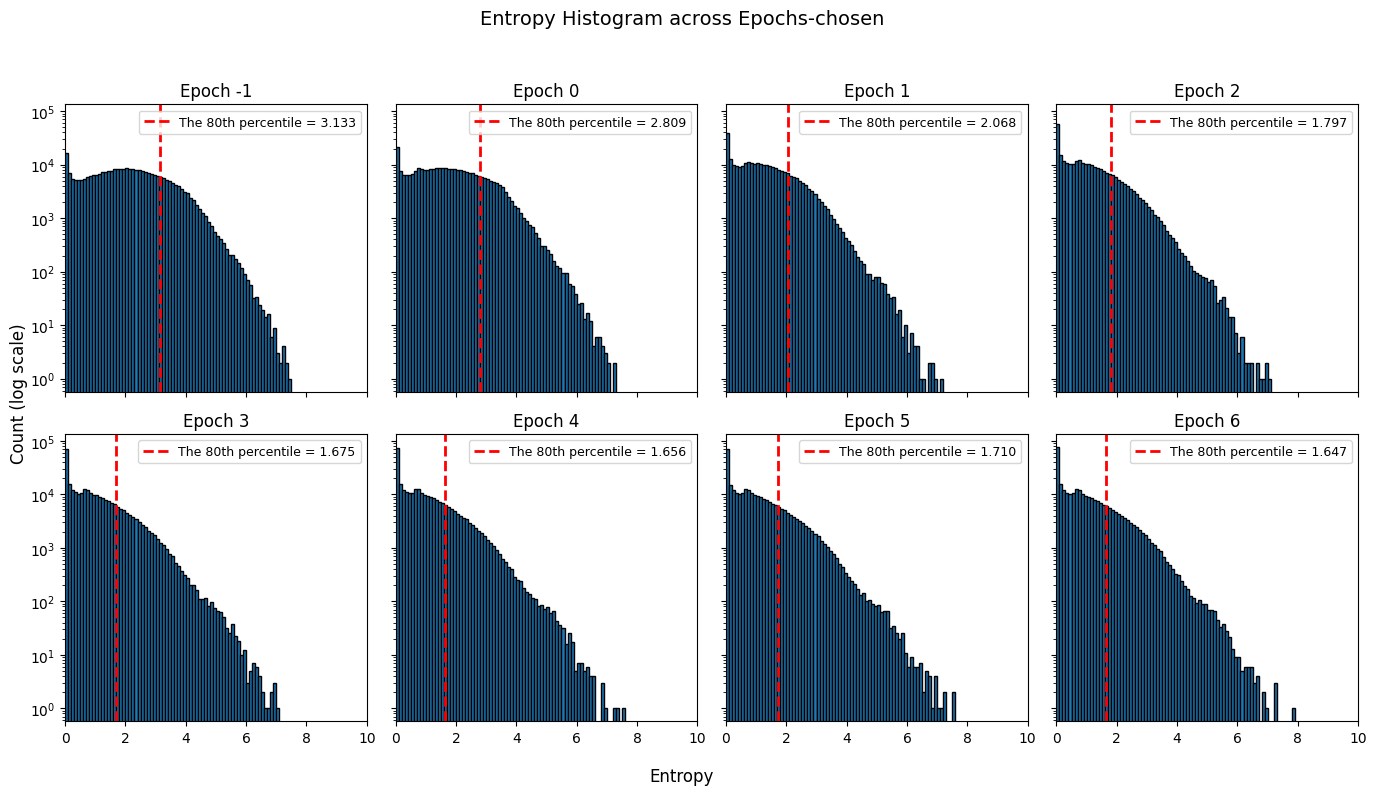

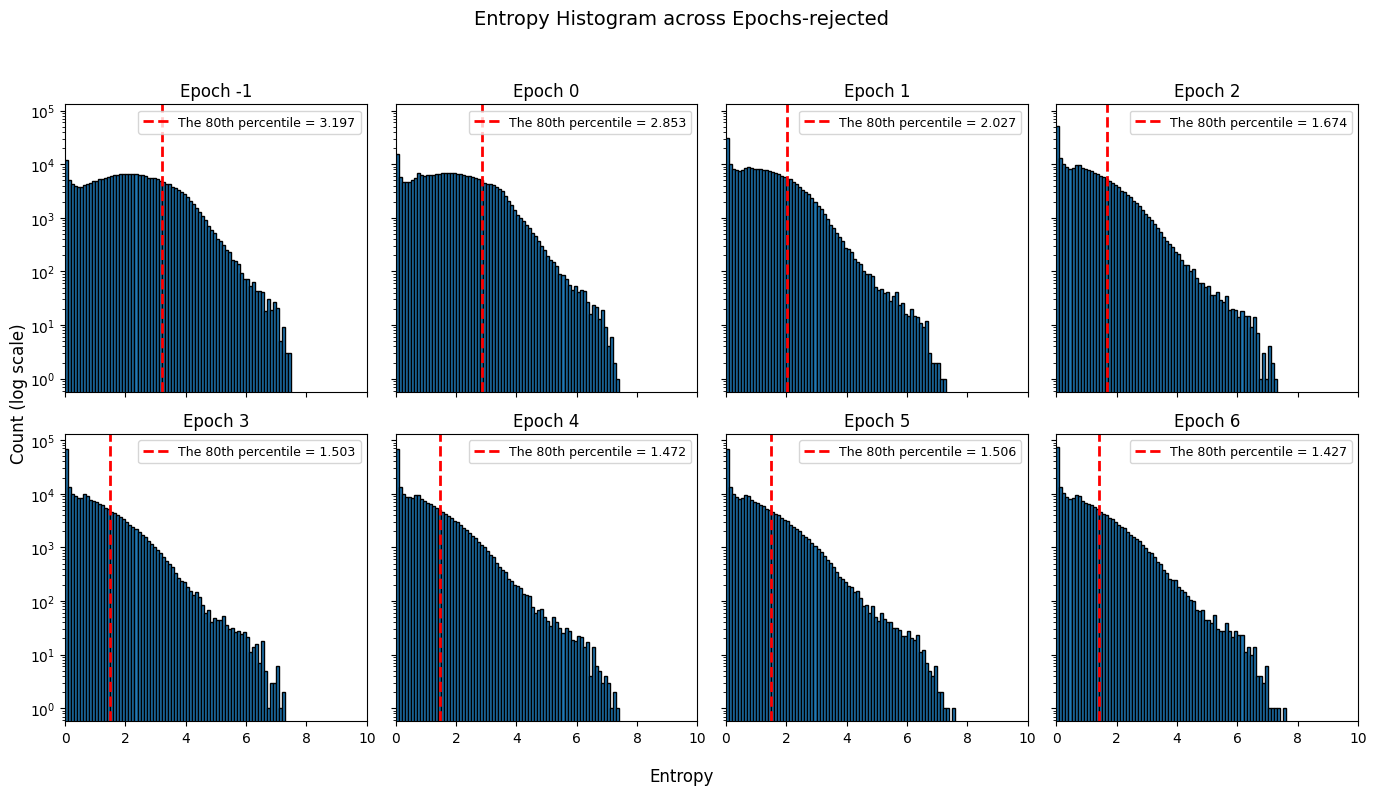

In [13]:
pretrained = "../src/exp_results/pretrained"
sft = "../src/exp_results/sft_qwen18_hh_ep2_1202"
exp_dir = "../src/exp_results/dpo_base_qwen18_hh_ep6_0105"

draw_graph(pretrained,sft,exp_dir,'chosen')
draw_graph(pretrained,sft,exp_dir,'rejected')

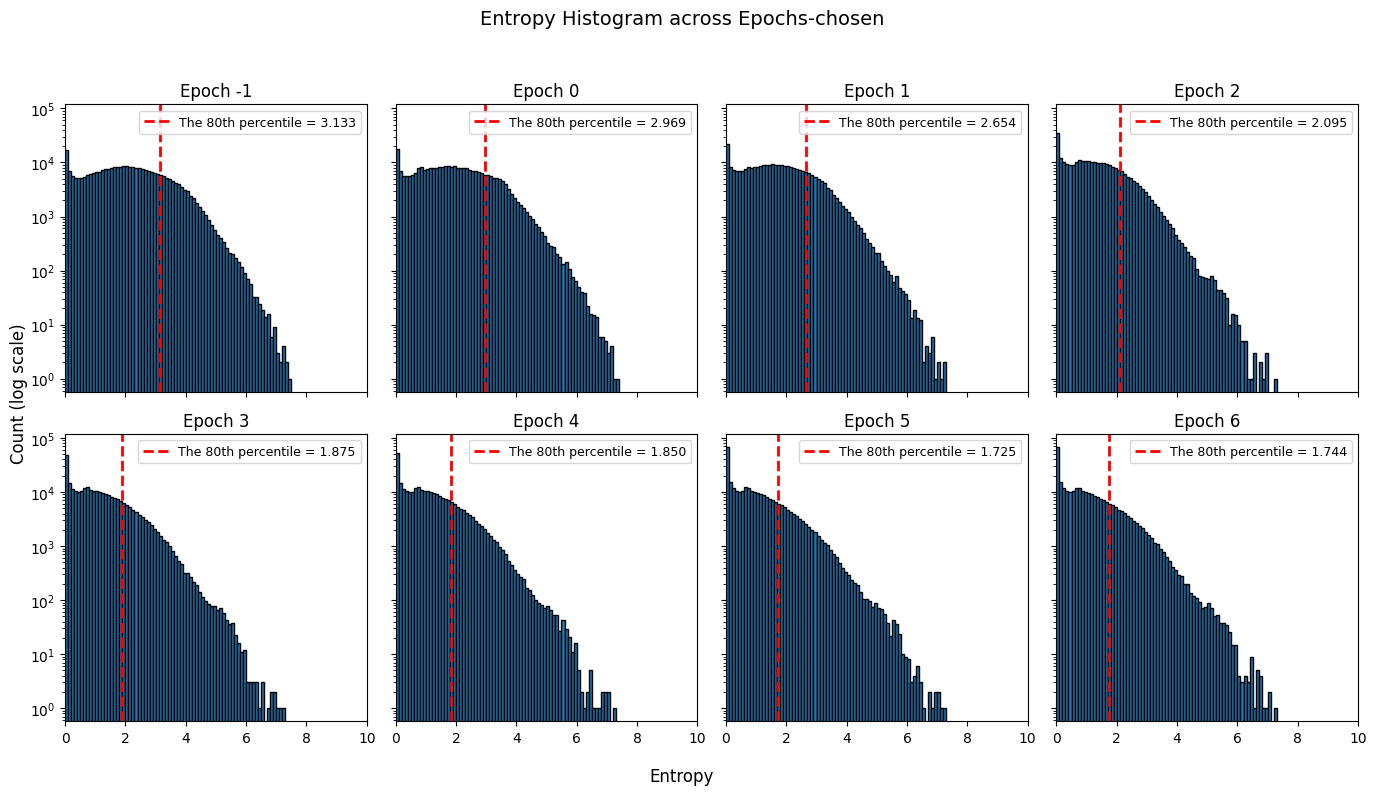

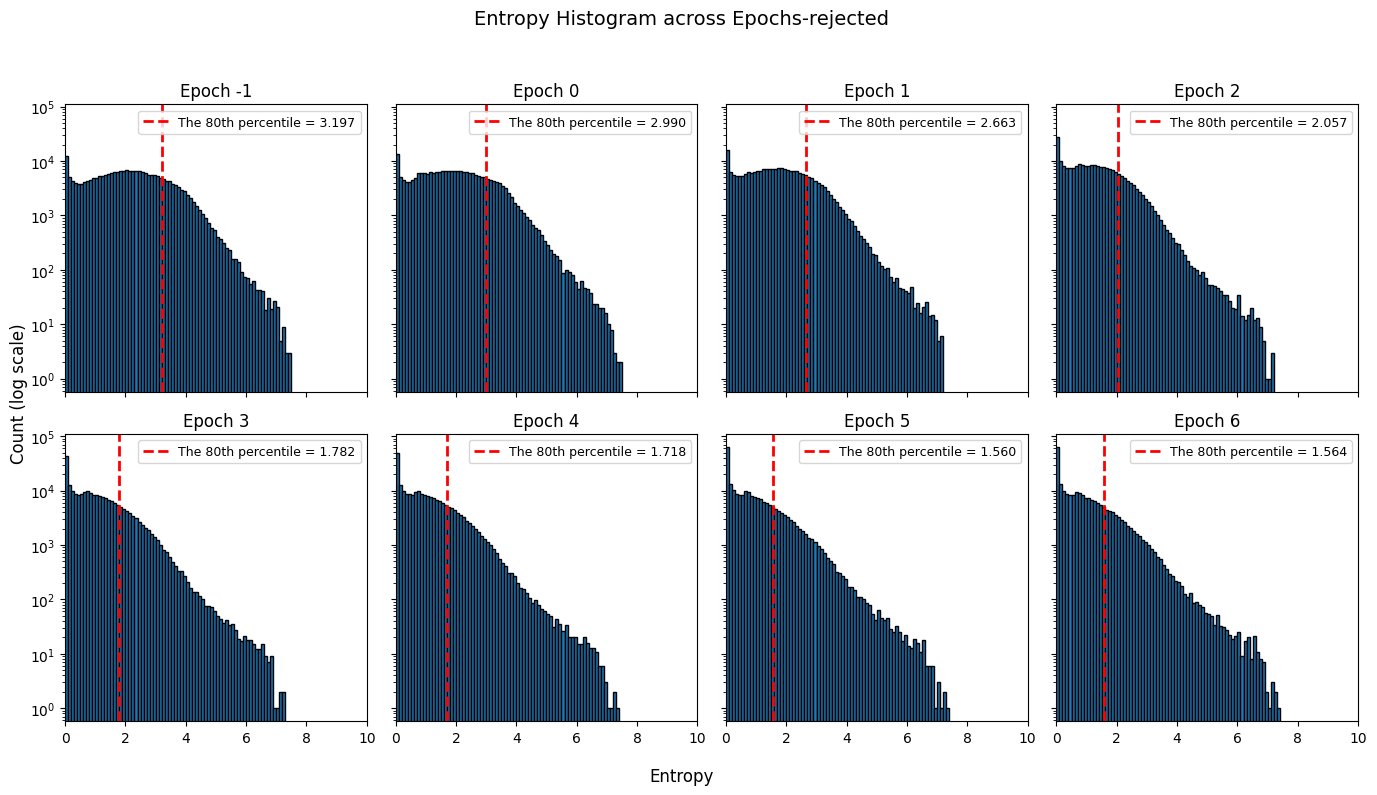

In [14]:
pretrained = "../src/exp_results/pretrained"
sft = "../src/exp_results/extend_sft_qwen18_hh_ep1_1202"
exp_dir = "../src/exp_results/dpo_extend_qwen18_hh_ep6_0105"

draw_graph(pretrained,sft,exp_dir,'chosen')
draw_graph(pretrained,sft,exp_dir,'rejected')

In [32]:
def load_items(file_path, branch):
    """
    branch: 'chosen' or 'rejected'
    """
    with open(file_path, "r") as f:
        data = json.load(f)

    items = []
    for token, info in data[branch].items():
        items.append({
            "token": token,
            "count": info["count"],
            "entropy": info["avg_entropy"]
        })

    return items

def select_top200(items, k=200):
    return sorted(
        items,
        key=lambda x: x["count"],
        reverse=True
    )[:k]


def split_entropy(items, n=100):
    sorted_items = sorted(
        items,
        key=lambda x: x["entropy"],
        reverse=True
    )
    return sorted_items[:n], sorted_items[n:2*n]

def to_wordcloud_dict(items):
    return {item["token"]: item["count"] for item in items}

from wordcloud import WordCloud

def draw_wordcloud(freqs, ax, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freqs)

    ax.imshow(wc.to_image(), interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)

def draw_branch_wordclouds(file_path, branch, axes):
    """
    axes: [ax_high, ax_low]
    """
    items = load_items(file_path, branch)

    if len(items) == 0:
        for ax in axes:
            ax.axis("off")
        return

    top200 = select_top200(items)
    high_e, low_e = split_entropy(top200)

    draw_wordcloud(
        to_wordcloud_dict(high_e),
        axes[0],
        f"{branch} | High Entropy (Top100 of Top200 freq)"
    )

    draw_wordcloud(
        to_wordcloud_dict(low_e),
        axes[1],
        f"{branch} | Low Entropy (Bottom100 of Top200 freq)"
    )
def draw_word_cloud(file_path):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    draw_branch_wordclouds(
        file_path,
        branch="chosen",
        axes=axes[0]
    )

    draw_branch_wordclouds(
        file_path,
        branch="rejected",
        axes=axes[1]
    )

    plt.tight_layout()
    plt.show()

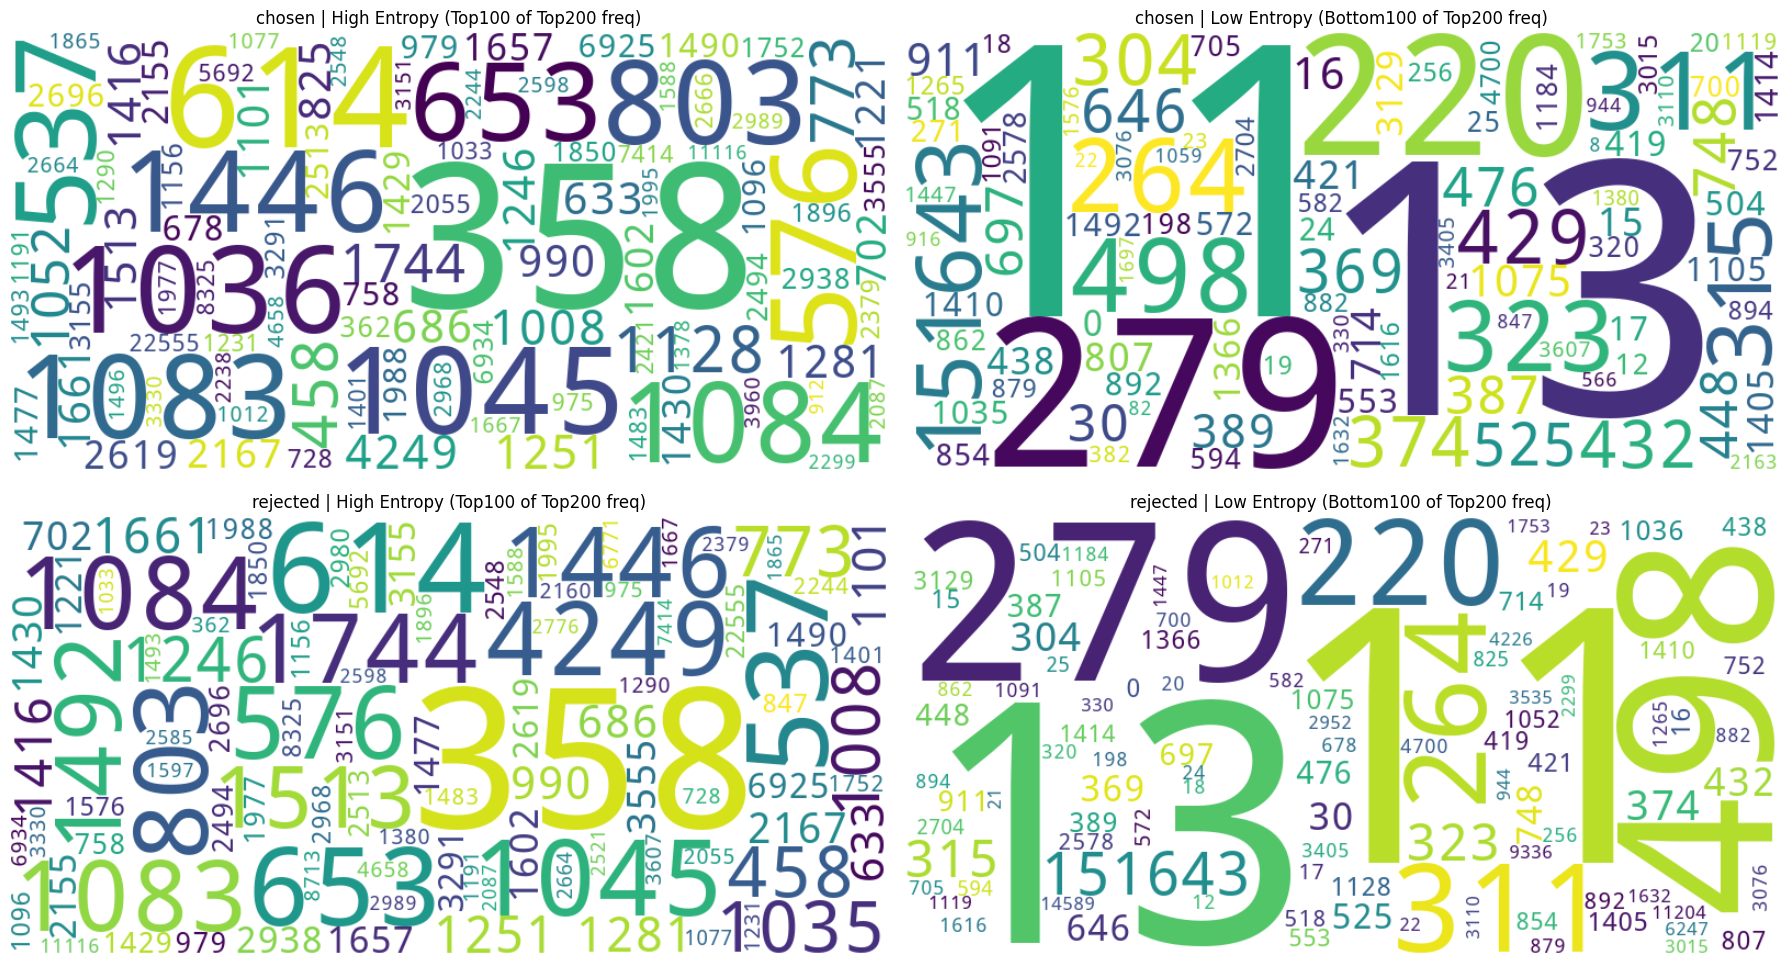

In [34]:
file_path = "../src/exp_results/pretrained/max_entropy_top3_words_epoch_1.json"
draw_word_cloud(file_path)


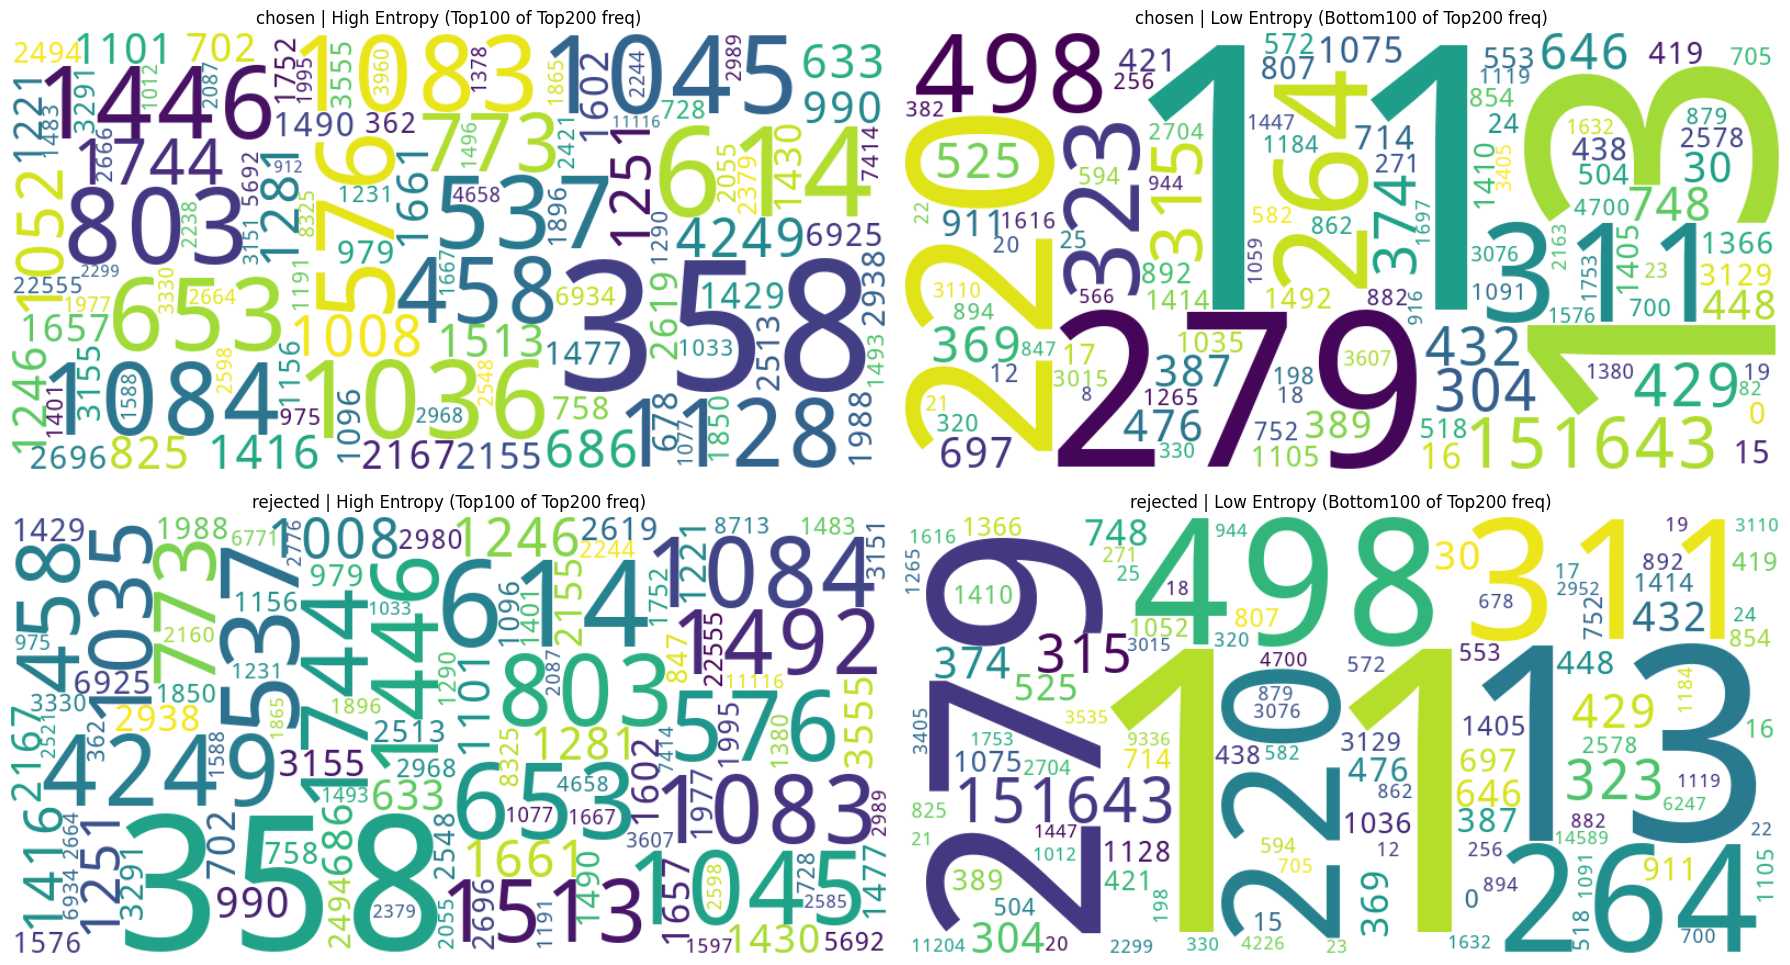

In [33]:
file_path = "../src/exp_results/extend_sft_qwen18_hh_ep1_1202/max_entropy_top3_words_epoch_1.json"
draw_word_cloud(file_path)
